PACE Stage: Plan
Project Background

This project analyzes historical YouTube Shorts data from Dr. Agustin Landivar's channel. The goal is to transform performance metrics into useful recommendations for content planning and business decision-making.

Business Problem

The organization needs to understand which videos and content characteristics are associated with stronger results in views, audience growth, click-through rate, and estimated revenue.

Primary Business Question

Which characteristics of YouTube Shorts are associated with stronger performance, and how can these findings improve the channel's content strategy?

Stakeholders
Dr. Agustin Landivar — CEO: Strategic content and channel growth decisions.
Content team: Selection of topics and future video ideas.
Video editors: Decisions related to video duration and viewing behavior.
Graphic designers: Visual decisions that may be evaluated in a future phase with additional data.
E-commerce team: Alignment of popular health topics with content for 

- [doctorlandivar.com](https://doctorlandivar.com)
- [finelandvitamins.com](https://finelandvitamins.com)

Key Analytical Questions

What is the overall performance of the analyzed YouTube Shorts?
Which videos generated the most and least views, estimated revenue, and new users?
How are views, impressions, click-through rate, and estimated revenue related?
How does video duration relate to performance and average view duration?
How does performance vary by publication date, month, and day of the week?
What is the distribution of new, recurring, occasional, and regular users?
Which words, topics, or title characteristics appear most frequently among high-performing videos?
Are there outliers that could distort averages or business conclusions?

Deliverables

Cleaned and anonymized dataset
Exploratory data analysis with Python
Business analysis with SQL
Tableau dashboard
Interactive web presentation
Documented GitHub repository
Data-driven recommendations
Limitations and Privacy

This analysis can identify associations but cannot prove causality.

The dataset does not contain website traffic, product transactions, thumbnail characteristics, or direct sales conversions. Therefore, it cannot determine whether a specific video caused product sales.

The original Excel file contains private business information and will not be published. Only anonymized or aggregated data will be included in the public portfolio.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Identify the project root regardless of the notebook's working directory

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_data_directory = project_root / "data" / "raw"
excel_files = list(raw_data_directory.glob("*.xlsx"))

print(f"Found root: {project_root.resolve()}")
print(f"Excel files found: {len(excel_files)}")
print(excel_files)

Found root: C:\Users\USUARIO1\Documents\youtube-shorts-performance-analysis
Excel files found: 1
[WindowsPath('c:/Users/USUARIO1/Documents/youtube-shorts-performance-analysis/data/raw/TODOS LOS SHORTS CON DATOS.xlsx')]


In [3]:
data_path = excel_files[0]
excel_workbook = pd.ExcelFile(data_path)
print(excel_workbook.sheet_names)

['Datos de la tabla', 'Datos del gráfico', 'Totales']


## PACE Stage: Analyze

### 1. Load the Raw Data

The main worksheet is loaded into a Pandas DataFrame. The raw dataset will remain unchanged so that every cleaning and transformation step can be documented and reproduced.

In [4]:
videos_raw = pd.read_excel(
    data_path,
    sheet_name="Datos de la tabla"
)

print(f"Rows: {videos_raw.shape[0]}")
print(f"Columns: {videos_raw.shape[1]}")

videos_raw.head()

Rows: 347
Columns: 13


,Contenido,Título del video,Tiempo de publicación del video,Duración,Usuarios nuevos,Usuarios recurrentes,Usuarios ocasionales,Usuarios habituales,Ingresos estimados (USD),Vistas,Impresiones,Tasa de clics de las impresiones (%),Duración promedio de vistas
0,Total,NaN,NaN,NaN,6594842,13306606,10717640,2588966,7582.878,138204991,241768987,4.71,0:01:08
1,zIXXepy6XR8,"Transforma Tu Noche, Transforma Tu Cuerpo 🌙 #b...","May 8, 2026",60.0,13508,290856,126914,163942,52.431,854603,58762,4.23,0:01:00
2,E2UQhp1fGwE,El secreto del colágeno que nadie te contó #co...,"May 6, 2026",77.0,192,25511,5573,19938,3.521,67564,38325,4.56,0:01:22
3,sBAzGcD35Dw,¿Dulce Veneno? El endulzante que alimenta al c...,"May 4, 2026",85.0,304,8988,2107,6881,1.306,26266,31679,3.79,0:01:24
4,JBT76wx6Eb0,¡El Secreto de la Eterna Juventud! ✨ Ácido Hia...,"Apr 29, 2026",91.0,225,18537,4015,14522,2.489,47497,58766,5.15,0:01:30


### 2. Inspect the Dataset Structure

The dataset structure is inspected before applying any transformation. This step identifies column names, data types, non-null values, and potential data quality issues.

In [5]:
videos_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Contenido                             347 non-null    str    
 1   Título del video                      346 non-null    str    
 2   Tiempo de publicación del video       346 non-null    str    
 3   Duración                              346 non-null    float64
 4   Usuarios nuevos                       347 non-null    int64  
 5   Usuarios recurrentes                  347 non-null    int64  
 6   Usuarios ocasionales                  347 non-null    int64  
 7   Usuarios habituales                   347 non-null    int64  
 8   Ingresos estimados (USD)              347 non-null    float64
 9   Vistas                                347 non-null    int64  
 10  Impresiones                           347 non-null    int64  
 11  Tasa de clics de las impresion

### 3. Audit Missing Values

Missing values are quantified before data cleaning to determine whether they represent data quality problems or expected summary-row behavior.

In [6]:
data_quality = pd.DataFrame({
    "data_type": videos_raw.dtypes.astype(str),
    "missing_values": videos_raw.isna().sum(),
    "missing_percentage": (videos_raw.isna().mean() * 100).round(2)
})

data_quality = data_quality.reset_index()
data_quality = data_quality.rename(columns={"index":"column"})

data_quality


,column,data_type,missing_values,missing_percentage
0,Contenido,str,0,0.00
1,Título del video,str,1,0.29
2,Tiempo de publicación del video,str,1,0.29
3,Duración,float64,1,0.29
4,Usuarios nuevos,int64,0,0.00
5,Usuarios recurrentes,int64,0,0.00
6,Usuarios ocasionales,int64,0,0.00
7,Usuarios habituales,int64,0,0.00
8,Ingresos estimados (USD),float64,0,0.00
9,Vistas,int64,0,0.00


### 4. Audit Duplicate Records

Duplicate rows and repeated video identifiers are checked before cleaning the dataset. Duplicate records could distort totals, averages, and business conclusions.

In [7]:
duplicates_row = videos_raw.duplicated().sum()
duplicates_video_ids = videos_raw["Contenido"].duplicated().sum()

print(f"Duplicate rows: {duplicates_row}")
print(f"Duplicate video IDs: {duplicates_video_ids}")


Duplicate rows: 0
Duplicate video IDs: 0


### 5. Separate the Summary Row

The YouTube export contains a summary row labeled `Total`. This row is stored separately because it represents aggregated channel metrics rather than an individual video. A clean working DataFrame is then created with video-level records only.

In [8]:
summary_rows = videos_raw.loc[
    videos_raw["Contenido"] == "Total"
].copy()

videos_clean = videos_raw.loc[
    videos_raw["Contenido"] != "Total"
].copy()

videos_clean.reset_index(drop=True, inplace=True)

print(f"Summary rows stored: {len(summary_rows)}")
print(f"Video rows retained: {len(videos_clean)}")

videos_clean.head(3)

Summary rows stored: 1
Video rows retained: 346


,Contenido,Título del video,Tiempo de publicación del video,Duración,Usuarios nuevos,Usuarios recurrentes,Usuarios ocasionales,Usuarios habituales,Ingresos estimados (USD),Vistas,Impresiones,Tasa de clics de las impresiones (%),Duración promedio de vistas
0,zIXXepy6XR8,"Transforma Tu Noche, Transforma Tu Cuerpo 🌙 #b...","May 8, 2026",60.0,13508,290856,126914,163942,52.431,854603,58762,4.23,0:01:00
1,E2UQhp1fGwE,El secreto del colágeno que nadie te contó #co...,"May 6, 2026",77.0,192,25511,5573,19938,3.521,67564,38325,4.56,0:01:22
2,sBAzGcD35Dw,¿Dulce Veneno? El endulzante que alimenta al c...,"May 4, 2026",85.0,304,8988,2107,6881,1.306,26266,31679,3.79,0:01:24


### 6. Standardize Column Names

The original Spanish column names are preserved in `videos_raw`. The working dataset uses descriptive English names in `snake_case` format to improve readability, consistency, and reproducibility.

In [9]:
column_mapping = {
    "Contenido": "video_id",
    "Título del video": "video_title",
    "Tiempo de publicación del video": "publish_date",
    "Duración": "video_duration_seconds",
    "Usuarios nuevos": "new_viewers",
    "Usuarios recurrentes": "returning_viewers",
    "Usuarios ocasionales": "casual_viewers",
    "Usuarios habituales": "regular_viewers",
    "Ingresos estimados (USD)": "estimated_revenue_usd",
    "Vistas": "views",
    "Impresiones": "impressions",
    "Tasa de clics de las impresiones (%)": "impressions_ctr_percent",
    "Duración promedio de vistas": "average_view_duration"
}

videos_clean = videos_clean.rename(columns=column_mapping)

videos_clean.columns.tolist()



['video_id',
 'video_title',
 'publish_date',
 'video_duration_seconds',
 'new_viewers',
 'returning_viewers',
 'casual_viewers',
 'regular_viewers',
 'estimated_revenue_usd',
 'views',
 'impressions',
 'impressions_ctr_percent',
 'average_view_duration']

### 7. Convert Publication Dates

The publication date is converted from text into a datetime data type. This enables chronological analysis and the creation of time-based features such as year, month, and day of the week.

In [10]:
videos_clean["publish_date"] = pd.to_datetime(
    videos_clean["publish_date"],
    format="mixed",
    errors="coerce"
)

print(f"Data type : {videos_clean['publish_date'].dtype}")
print(f"Invalid dates: {videos_clean['publish_date'].isna().sum()}")
print(f"Earliest publish date: {videos_clean['publish_date'].min()}")
print(f"Latest publish date: {videos_clean['publish_date'].max()}")

Data type : datetime64[us]
Invalid dates: 0
Earliest publish date: 2023-05-31 00:00:00
Latest publish date: 2026-05-08 00:00:00


### 8. Convert Average View Duration to Seconds

The average view duration is stored as text in `hours:minutes:seconds` format. It is converted into total seconds to enable numerical analysis and comparisons with video duration.

In [11]:
average_view_timedelta = pd.to_timedelta(
    videos_clean["average_view_duration"],
    errors="coerce"
)

videos_clean["average_view_duration_seconds"] = (
    average_view_timedelta.dt.total_seconds()
)

print(
    f"Invalid durations: "
    f"{videos_clean['average_view_duration_seconds'].isna().sum()}"
)

videos_clean[
    [
        "average_view_duration",
        "average_view_duration_seconds"
    ]
].head()




Invalid durations: 0


,average_view_duration,average_view_duration_seconds
0,0:01:00,60.0
1,0:01:22,82.0
2,0:01:24,84.0
3,0:01:30,90.0
4,0:00:45,45.0


### 9. Review Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to understand their distributions, typical values, variability, and potential outliers.

In [12]:
numeric_columns = [
    "video_duration_seconds",
    "new_viewers",
    "returning_viewers",
    "casual_viewers",
    "regular_viewers",
    "estimated_revenue_usd",
    "views",
    "impressions",
    "impressions_ctr_percent",
    "average_view_duration_seconds"
]

numeric_summary = (
    videos_clean[numeric_columns]
    .describe()
    .transpose()
    .round(2)
)

numeric_summary


,count,mean,std,min,25%,50%,75%,max
video_duration_seconds,346.0,65.60,23.15,9.00,54.00,60.00,73.75,173.00
new_viewers,346.0,16798.74,47958.77,70.00,610.00,1833.50,9313.50,583832.00
returning_viewers,346.0,199107.66,324751.78,4858.00,33889.25,78784.00,205879.75,2312814.00
casual_viewers,346.0,162085.15,316393.71,1524.00,9379.00,37938.50,152922.00,2312613.00
regular_viewers,346.0,37022.51,47461.99,71.00,8057.75,20850.00,44857.00,258750.00
estimated_revenue_usd,346.0,19.15,28.75,0.71,4.19,8.07,20.04,184.77
views,346.0,347234.78,513511.77,10841.00,79732.75,156378.50,351753.75,3352263.00
impressions,346.0,671259.86,2171445.02,21585.00,88510.75,162364.50,540957.25,29415236.00
impressions_ctr_percent,346.0,4.85,0.94,2.02,4.34,4.92,5.50,7.85
average_view_duration_seconds,346.0,67.45,17.87,22.00,56.00,67.00,79.00,144.00


#### Initial Observations

- All numerical variables contain 346 valid records.
- Views, impressions, revenue, and viewer metrics have means considerably higher than their medians, suggesting right-skewed distributions and potential high-performing outliers.
- The impressions click-through rate is more stable, with a mean of 4.85% and a median of 4.92%.
- The median video duration is 60 seconds.
- Additional validation is required before unusual values are classified as errors or legitimate outliers.

### 10. Validate Numerical Business Rules

Numerical variables are checked for impossible values and internal inconsistencies before exploratory visualizations are created.

In [13]:
validation_results = {
    "negative_numeric_values":int(
        (videos_clean[numeric_columns] <= 0).sum().sum()
    ),
    "non_positive_video_duration":int(
        (videos_clean["video_duration_seconds"] <= 0).sum()
    ),
    "invalid_ctr_values": int(
        (
            ~videos_clean["impressions_ctr_percent"].between(0, 100)
        ).sum()
    )
}

pd.Series(validation_results, name="issues_found")



negative_numeric_values        0
non_positive_video_duration    0
invalid_ctr_values             0
Name: issues_found, dtype: int64

### 11. Finalize Duration Variables

After validating the duration conversions, both duration variables are stored as integer seconds. The original text-based average view duration is removed from the working dataset because the raw values remain preserved in `videos_raw`.


In [14]:
videos_clean["video_duration_seconds"] = (
    videos_clean["video_duration_seconds"].astype("int64")
)

videos_clean["average_view_duration_seconds"] = (
    videos_clean["average_view_duration_seconds"].astype("int64")
)

videos_clean = videos_clean.drop(
    columns=["average_view_duration"]
)


videos_clean[
    [
        "video_duration_seconds",
        "average_view_duration_seconds"
    ]
].head()


,video_duration_seconds,average_view_duration_seconds
0,60,60
1,77,82
2,85,84
3,91,90
4,51,45


### 12. Create Publication Date Features

Year, month, and day of the week are extracted from publication dates to support grouped comparisons. These comparisons are descriptive and do not establish an optimal publishing schedule.

In [15]:
videos_clean["publish_year"] = videos_clean["publish_date"].dt.year

videos_clean["publish_month"] = videos_clean["publish_date"].dt.month

videos_clean["publish_day_of_week"] = videos_clean["publish_date"].dt.day_name()

videos_clean[
    [
        "publish_date",
        "publish_year", 
        "publish_month",
        "publish_day_of_week"
    ]
].head()

,publish_date,publish_year,publish_month,publish_day_of_week
0,2026-05-08,2026,5,Friday
1,2026-05-06,2026,5,Wednesday
2,2026-05-04,2026,5,Monday
3,2026-04-29,2026,4,Wednesday
4,2026-04-27,2026,4,Monday


### 13. Validate the Working Dataset

After cleaning and feature creation, the dataset is checked for record count, missing values, duplicate video identifiers, and duplicate column names.

In [16]:
working_data_checks = pd.Series(
    {
        "videos_rows": len(videos_clean),
        "columns": videos_clean.shape[1],
        "missing_values": videos_clean.isna().sum().sum(),
        "duplicate_video_ids": videos_clean["video_id"].duplicated().sum(),
        "duplicate_column_names": videos_clean.columns.duplicated().sum()
    },name="result"
)

working_data_checks

videos_rows               346
columns                    16
missing_values              0
duplicate_video_ids         0
duplicate_column_names      0
Name: result, dtype: int64

In [17]:
videos_clean.columns.tolist()

['video_id',
 'video_title',
 'publish_date',
 'video_duration_seconds',
 'new_viewers',
 'returning_viewers',
 'casual_viewers',
 'regular_viewers',
 'estimated_revenue_usd',
 'views',
 'impressions',
 'impressions_ctr_percent',
 'average_view_duration_seconds',
 'publish_year',
 'publish_month',
 'publish_day_of_week']

### 14. Explore the Distribution of Views

A histogram is used to examine how views are distributed across videos. Mean and median reference lines help assess whether a small number of high-performing videos influences the average.

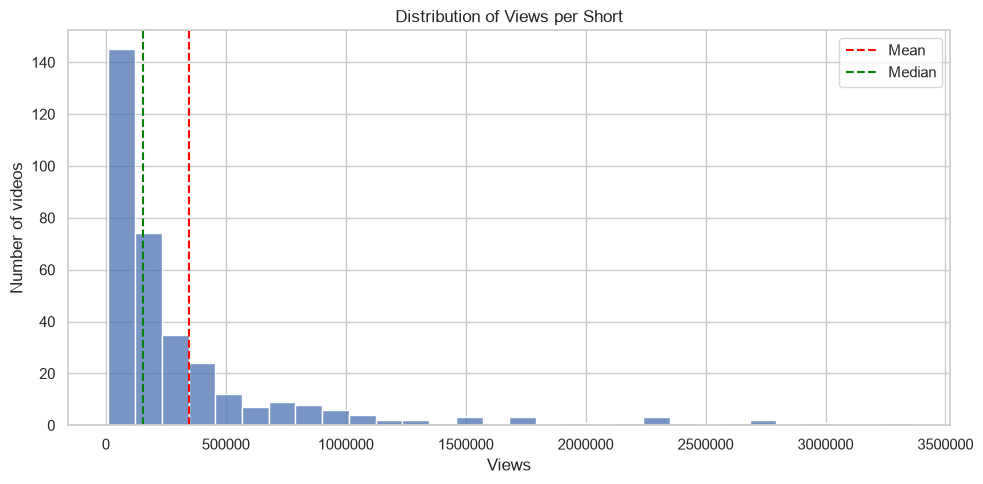

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=videos_clean,
    x="views",
    bins=30,
    ax=ax
)

ax.axvline(
    videos_clean["views"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

ax.axvline(
    videos_clean["views"].median(),
    color="green",
    linestyle="--",
    label="Median"
)

ax.set(
    title="Distribution of Views per Short",
    xlabel="Views",
    ylabel="Number of videos"
)

ax.ticklabel_format(style="plain", axis="x")
ax.legend()
plt.tight_layout()
plt.show()


#### Findings: Views Distribution

Views are strongly right-skewed: most videos fall within the lower view ranges, while a small number reach much higher values.

Mean views are approximately 347,235, compared with a median of 156,379. The mean is about 2.22 times the median, indicating that high-view videos pull the average upward.

The median will serve as the primary reference for typical video performance, alongside the mean. High-view observations will be investigated rather than automatically removed.

### 15. Flag High-View Outliers Using the IQR Rule

The upper IQR fence is used to identify unusually high view counts. Flagged videos are retained for investigation because exceptional performance does not necessarily indicate a data error.

In [19]:
views_q1 = videos_clean["views"].quantile(0.25)
views_q3 = videos_clean["views"].quantile(0.75)

views_iqr = views_q3 - views_q1
views_upper_fence = views_q3 + 1.5 * views_iqr

high_views_mask = videos_clean["views"] > views_upper_fence

print(f"Q1: {views_q1:,.2f}")
print(f"Q3: {views_q3:,.2f}")
print(f"IQR: {views_iqr:,.2f}")
print(f"Upper fence: {views_upper_fence:,.2f}")
print(f"Videos above the upper fence: {high_views_mask.sum()}")





Q1: 79,732.75
Q3: 351,753.75
IQR: 272,021.00
Upper fence: 759,785.25
Videos above the upper fence: 41


In [20]:
high_view_videos = videos_clean.loc[high_views_mask].copy()

high_view_videos = high_view_videos.sort_values(
    by="views",
    ascending=False
)

high_view_videos[
    [
        "video_title",
        "publish_date",
        "video_duration_seconds",
        "views",
        "estimated_revenue_usd"
    ]
].head(10)



,video_title,publish_date,video_duration_seconds,views,estimated_revenue_usd
319,Veneno Para Los Riñones #shorts #short,2023-08-08,55,3352263,153.077
259,Hierbabuena Para Todo! #hierbabuena #saludabl...,2024-05-27,57,2941002,184.772
244,Agua de Manzana Con Canela @DrAgustinLandivar,2024-09-09,60,2785436,171.773
320,VITAMINAS PARA REJUVENECER,2023-08-04,55,2742260,121.078
264,Agua de Linaza Todos Los Días #jugosnaturales ...,2024-04-22,60,2610416,127.810
254,Vitaminas Para Revertir La Pérdida de Memoria ...,2024-07-01,60,2442818,134.739
294,Vitaminas Para El Cabello #tips #bellezanatura...,2023-10-11,54,2308078,131.886
256,NO CONSUMAS CANELA #bienestar #saludable,2024-06-17,60,2278318,143.964
262,Vídeo Completo Arriba ☝️☝️☝️ #natural #bienestar,2024-05-06,60,2243381,140.997
175,❌ ¡NO MEZCLES esto con AGUACATE/PALTA! Podrías...,2025-07-28,51,2185640,117.131


### 16. Measure View Concentration

**PACE stage:** Analyze  
**EDA step:** Univariate analysis — view concentration

What percentage of dataset views comes from the 41 videos flagged by the upper IQR fence?

Their share of videos is compared with their share of views to assess how concentrated performance is. Calculations use the 346 video-level records, excluding the export's summary row.

In [21]:
total_views = videos_clean["views"].sum()
high_view_total = high_view_videos["views"].sum()

high_views_share = (high_view_total / total_views) * 100
high_video_share = (len(high_view_videos) / len(videos_clean)) * 100

print(f"Flagged videos: {len(high_view_videos)}")
print(f"Share of videos: {high_video_share:.2f}%")
print(f"Share of dataset views: {high_views_share:.2f}%")



Flagged videos: 41
Share of videos: 11.85%
Share of dataset views: 51.37%


#### Findings: View Concentration

The 41 videos flagged by the upper IQR fence represent 11.85% of the dataset but account for 51.37% of its views. The remaining 305 videos account for 48.63%.

This concentration supports reporting the median alongside the mean when describing typical performance. Flagged videos will be retained and compared with other videos to explore potential patterns.

These findings apply to the 346 exported video records, not necessarily to the entire channel. They do not establish what caused higher view counts.

### 17. Compare Video Duration Across View Groups

**PACE stage:** Analyze  
**EDA step:** Bivariate analysis — group comparison

Do videos above the upper IQR fence differ in duration from the remaining videos?

Video counts, mean duration, and median duration are compared across groups. Any differences are descriptive and do not establish that duration causes higher views.

In [22]:
duration_comparison = (
    videos_clean
    .assign(high_views=high_views_mask)
    .groupby("high_views")["video_duration_seconds"]
    .agg(
        video_count="count",
        mean_duration_seconds="mean",
        median_duration_seconds="median"
    )
    .rename(index={
        False: "Other videos",
        True: "Above upper IQR fence"
    }
    ).round(2)
)

duration_comparison






,video_count,mean_duration_seconds,median_duration_seconds
high_views,,,
Other videos,305,66.77,60.0
Above upper IQR fence,41,56.85,59.0


#### Findings: Duration by View Group

Videos above the upper IQR fence have a mean duration of 56.85 seconds, compared with 66.77 seconds for other videos—a difference of 9.92 seconds.

However, median durations are nearly identical: 59 and 60 seconds, respectively. The difference in means therefore warrants examining the full duration distributions.

These descriptive results do not establish an optimal video length or show that shorter duration causes higher views. Publication timing and content differences remain potential alternative explanations.

### 18. Visualize Duration Across View Groups

**PACE stage:** Analyze  
**EDA step:** Bivariate analysis — distribution comparison

Boxplots compare median duration, spread, and potential duration outliers across view groups. This helps investigate the difference in means despite similar medians.

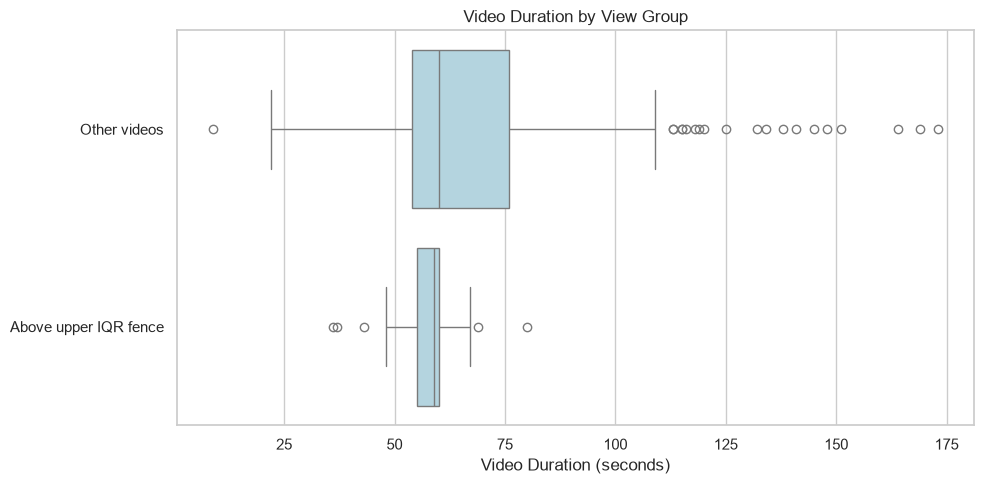

In [23]:
duration_plot_data = videos_clean.assign(
    view_group = high_views_mask.map({
        False: "Other videos",
        True: "Above upper IQR fence"
    })
)

fig, ax = plt.subplots(figsize=(10,5))

sns.boxplot(    
    data=duration_plot_data,
    x="video_duration_seconds",
    y="view_group",
    order=["Other videos", "Above upper IQR fence"],
    color="lightblue",
    ax=ax
)

ax.set(
    title="Video Duration by View Group",
    xlabel="Video Duration (seconds)",
    ylabel=""
)

plt.tight_layout()
plt.show()


#### Findings: Duration Distributions

Both groups have similar median durations: 60 seconds for other videos and 59 seconds for videos above the upper views fence.

The high-view group has a narrower central duration range around one minute. Other videos show greater variability and a longer upper tail, helping explain their higher mean duration despite similar medians.

Points outside the whiskers represent potential duration outliers within each group, not data errors. These descriptive differences do not establish an optimal duration or a causal effect on views.

In [24]:
year_comparison = (
    videos_clean
    .assign(high_views = high_views_mask)
    .groupby("publish_year")
    .agg(
        video_count = ("video_id", "count"),
        high_view_count = ("high_views", "sum")
    )
)

year_comparison["high_view_percentage"] = (
    year_comparison["high_view_count"]
    / year_comparison["video_count"]
    * 100
).round(2)

year_comparison

,video_count,high_view_count,high_view_percentage
publish_year,,,
2023,66,10,15.15
2024,52,18,34.62
2025,163,8,4.91
2026,65,5,7.69


#### Findings: High-View Videos by Publication Year

Videos published in 2024 have the highest share above the global views threshold: 18 of 52 videos (34.62%). The corresponding shares are 15.15% for 2023, 4.91% for 2025, and 7.69% for 2026.

The concentration differs across publication years, so publication timing should be considered when interpreting the duration comparison.

These are publication cohorts, not annual channel results. Differences may reflect content, exposure time, or other factors. The export's measurement period must be confirmed before drawing stronger conclusions.

### 20. Confirm the Measurement Period

**PACE stage:** Analyze  
**EDA step:** Data context validation — measurement period

The source owner confirmed that the export used YouTube Analytics' “Lifetime” option and was intended to include all Shorts.

View counts therefore reflect accumulation through the export cutoff, with different exposure times across publication dates. Comparisons by year and duration are descriptive and do not measure performance over equal post-publication windows.

The export cutoff and the difference between the summary row and the exported video totals remain to be checked.

In [25]:
daily_totals = pd.read_excel(
    data_path,
    sheet_name = "Totales"
)

export_dates = pd.to_datetime(
    daily_totals["Fecha"],
    errors="coerce"
)

print(f"Unparsed or missing dates: {export_dates.isna().sum()}")
print(f"First date in export: {export_dates.min()}")
print(f"Last date in export: {export_dates.max()}")



Unparsed or missing dates: 0
First date in export: 2015-12-11 00:00:00
Last date in export: 2026-05-24 00:00:00


### 21. Reconcile Exported Views with the Summary Row

**PACE stage:** Analyze  
**EDA step:** Data validation — total reconciliation

The sum of views across the 346 exported videos is compared with the export's summary row. Any difference is quantified without assuming its cause.

In [26]:
summary_views = summary_rows["Vistas"].iloc[0]
exported_views = videos_clean["views"].sum()

views_difference = summary_views - exported_views
views_coverage_percentage = (exported_views / summary_views) * 100

print(f"Summary views: {summary_views:,.0f}")
print(f"Exported video views: {exported_views:,.0f}")
print(f"Difference: {views_difference:,.0f}")
print(f"Views coverage: {views_coverage_percentage:.2f}%")


Summary views: 138,204,991
Exported video views: 120,143,235
Difference: 18,061,756
Views coverage: 86.93%


#### Findings: Views Reconciliation

The 346 exported video records contain 120,143,235 views, compared with 138,204,991 in the summary row.

The difference is 18,061,756 views (13.07% of the summary total). Exported records therefore account for 86.93% of the reported summary views.

The cause of this discrepancy remains unresolved. All 346 individual video records were retained during cleaning; only the summary row was separated.

Subsequent findings apply to the exported video records. No missing records or view counts will be inferred or fabricated to reconcile the difference.

### 22. Compare Duration Within Publication Years

**PACE stage:** Analyze  
**EDA step:** Multivariate exploration — comparison by publication year

Does the duration difference between view groups persist within each publication year?

Video counts, mean duration, and median duration are compared by year and view group. The global views threshold is retained. Grouping by year does not equalize exposure time or establish causality.

In [29]:
duration_by_year = (
    videos_clean 
    .assign(
        view_group=high_views_mask.map({
            False:"Other videos",
            True:"Above upper IQR fence"
        })
    )
    .groupby(["publish_year","view_group"])
    .agg(
        video_count=("video_id","count"),
        mean_duration_seconds=("video_duration_seconds","mean"),
        median_duration_seconds=("video_duration_seconds","median")
    )
    .round(2)
)

duration_by_year

video_count  mean_duration_seconds  \
publish_year view_group                                                  
2023         Above upper IQR fence           10                  55.30   
             Other videos                    56                  56.20   
2024         Above upper IQR fence           18                  59.61   
             Other videos                    34                  58.82   
2025         Above upper IQR fence            8                  53.88   
             Other videos                   155                  67.06   
2026         Above upper IQR fence            5                  54.80   
             Other videos                    60                  80.40   

                                    median_duration_seconds  
publish_year view_group                                      
2023         Above upper IQR fence                     55.5  
             Other videos                              57.5  
2024         Above upper IQR fence                     60.0  
             Other videos                              60.0  
2025         Above upper IQR fence                     51.0  
             Other videos                              60.0  
2026         Above upper IQR fence                     51.0  
             Other videos                              72.0

#### Findings: Duration Differences Within Publication Years

The duration difference between view groups is not consistent across publication years.

Mean durations are similar in 2023 and 2024. In 2025 and 2026, videos above the global views threshold are shorter on average by 13.18 and 25.60 seconds, respectively. Median durations also differ in these later cohorts.

The pooled comparison therefore masks variation across publication years. The later high-view groups contain only eight and five videos, and exposure time and content differences remain unaccounted for.

These results do not support a universal optimal duration or establish that shorter videos cause higher views.

### 23. Explore Views and Estimated Revenue

**PACE stage:** Analyze  
**EDA step:** Bivariate analysis — views and estimated revenue

A scatter plot examines the relationship between views and estimated YouTube revenue across the 346 exported videos.

Each point represents one video. Revenue refers to the export's estimated revenue metric, not website sales. Lifetime totals reflect unequal exposure periods.

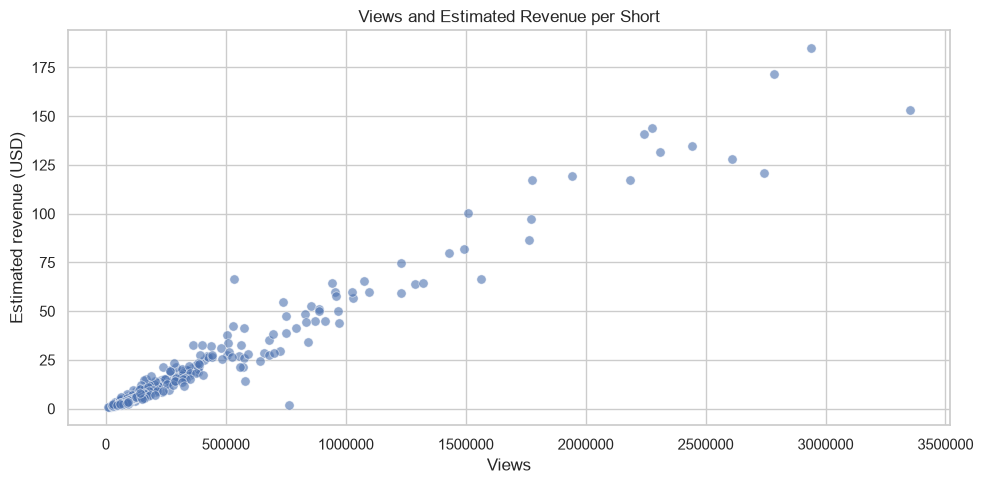

In [31]:
fig, ax = plt.subplots(figsize=(10,5))

sns.scatterplot(
    data=videos_clean,
    x="views",
    y="estimated_revenue_usd",
    alpha=0.6,
    s=45,
    ax=ax
)

ax.set(
    title="Views and Estimated Revenue per Short",
    xlabel="Views",
    ylabel="Estimated revenue (USD)"
)

ax.ticklabel_format(style="plain",axis="x")

plt.tight_layout()
plt.show()

#### Findings: Views and Estimated Revenue

The scatter plot shows a clear positive association between views and estimated revenue. However, videos with similar view counts can have different revenue totals, and the most-viewed video is not the highest-revenue video.

One observation near 750,000 views has unusually low revenue relative to the surrounding pattern and warrants individual inspection.

These are visual observations, not a quantified correlation or a causal explanation. The dataset does not establish why revenue differs across videos.

### 24. Inspect a Visually Unusual Revenue Observation

**PACE stage:** Analyze  
**EDA step:** Bivariate analysis — observation inspection

The scatter plot shows an observation near 750,000 views with unusually low estimated revenue. A targeted filter retrieves nearby records for inspection.

The filter bounds are visual search criteria, not statistical outlier thresholds. Matching records are retained without modification.

In [32]:
revenue_review_mask = (
    videos_clean["views"].between(600_000, 900_000)
    & (videos_clean["estimated_revenue_usd"] < 10)
)

revenue_review = videos_clean.loc[
    revenue_review_mask,
    [
        "video_id",
        "video_title",
        "publish_date",
        "video_duration_seconds",
        "views",
        "estimated_revenue_usd"
    ]
].copy()

print(f"Videos selected for review: {len(revenue_review)}")

with pd.option_context("display.max_colwidth", None):
    display(revenue_review)


Videos selected for review: 1


,video_id,video_title,publish_date,video_duration_seconds,views,estimated_revenue_usd
274,kfs_-SHckls,Para que Sirve la Cola de Caballo #medicinanatural #bienestar #sano,2024-02-05,60,761693,2.045


#### Findings: Unusual Revenue Observation

The targeted filter identified one video: "Para que Sirve la Cola de Caballo…", published on February 5, 2024.

It records 761,693 views and USD 2.045 in estimated revenue. Its view count also exceeds the global upper IQR fence, illustrating that unusually high views do not necessarily correspond to high revenue.

The reason for this discrepancy cannot be established from the available fields. The record is retained unchanged and flagged for source verification.

### 25. Calculate Estimated Revenue per 1,000 Views

**PACE stage:** Analyze  
**EDA step:** Feature engineering — revenue normalization

Estimated revenue is divided by exported views and multiplied by 1,000 to compare revenue relative to view counts.

This dataset-derived ratio is not assumed to match YouTube's official RPM metric. It describes historical results and does not represent a guaranteed payout rate.

In [41]:
valid_views = videos_clean["views"][videos_clean["views"] > 0]

videos_clean["estimated_revenue_per_1000_views_usd"] = (
    videos_clean["estimated_revenue_usd"] 
    / valid_views 
    * 1000
)

print(
    "Missing revenue ratios:",
    videos_clean["estimated_revenue_per_1000_views_usd"].isna().sum()
)

videos_clean[
    [
        "views",
        "estimated_revenue_usd",
        "estimated_revenue_per_1000_views_usd"
    ]
].head()

Missing revenue ratios: 0


,views,estimated_revenue_usd,estimated_revenue_per_1000_views_usd
0,854603,52.431,0.061351
1,67564,3.521,0.052114
2,26266,1.306,0.049722
3,47497,2.489,0.052403
4,133048,9.315,0.070012


### 26. Summarize Estimated Revenue per 1,000 Views

**PACE stage:** Analyze  
**EDA step:** Univariate analysis — derived revenue metric

Descriptive statistics summarize the dataset-derived revenue ratio across videos. Each video receives equal weight in this summary; the mean is not the overall revenue-to-views ratio.

In [42]:
revenue_ratio_summary = (
    videos_clean["estimated_revenue_per_1000_views_usd"]
    .describe()
    .round(4)
)

revenue_ratio_summary

count    346.0000
mean       0.0548
std        0.0127
min        0.0027
25%        0.0474
50%        0.0535
75%        0.0615
max        0.1244
Name: estimated_revenue_per_1000_views_usd, dtype: float64

#### Findings: Estimated Revenue per 1,000 Views

The median dataset-derived revenue ratio is USD 0.0535 per 1,000 views. The middle 50% of videos falls between USD 0.0474 and USD 0.0615.

The mean of individual video ratios is USD 0.0548. This is not the aggregate revenue-to-views ratio.

The previously flagged video records approximately USD 0.002685 per 1,000 views, about 95% below the median and consistent with the rounded minimum. Its underlying cause remains unverified, so the record is retained unchanged.

### 27. Inspect the Lowest Revenue Ratios

**PACE stage:** Analyze  
**EDA step:** Exploratory analysis — inspection of low values

The five lowest estimated revenue ratios are inspected to identify the minimum and compare nearby observations. Ranking alone does not establish statistical outliers or explain their causes.

In [43]:
lowest_revenue_ratios = (
    videos_clean
    .sort_values(
        by="estimated_revenue_per_1000_views_usd",
        ascending=True
    )
    .head(5)
)

with pd.option_context("display.max_colwidth", None):
    display(
        lowest_revenue_ratios[
            [
                "video_title",
                "publish_date",
                "views",
                "estimated_revenue_usd",
                "estimated_revenue_per_1000_views_usd"
            ]
        ]
    )

,video_title,publish_date,views,estimated_revenue_usd,estimated_revenue_per_1000_views_usd
274,Para que Sirve la Cola de Caballo #medicinanatural #bienestar #sano,2024-02-05,761693,2.045,0.002685
76,¿Por qué te levantas tanto a orinar? ¡Cuidado! #vejiga,2025-12-10,581450,14.288,0.024573
317,No Esta Científicamente Comprobado #shorts #medicina #salud #remedioscaseros,2023-08-14,92094,2.422,0.026299
87,Error Común con la Próstata #prostatasana,2025-11-25,63973,1.709,0.026714
337,gripe con mucha frecuencia#shorts,2023-06-24,150023,4.823,0.032148


#### Findings: Lowest Revenue Ratios

"Para que Sirve la Cola de Caballo…" has the lowest estimated revenue ratio in the dataset: approximately USD 0.002685 per 1,000 views.

The next-lowest ratio is USD 0.024573, approximately 9.15 times higher. This substantial separation reinforces the priority of checking the first record against the source report.

All records are retained unchanged. The ranking does not explain the differences or establish that any value is erroneous.

### 28. Compare Aggregate and Per-Video Revenue Ratios

**PACE stage:** Analyze  
**EDA step:** Metric aggregation — aggregate versus per-video ratios

The aggregate ratio divides total estimated revenue by total views across the 346 exported videos and multiplies by 1,000.

Unlike the unweighted mean of individual video ratios, the aggregate ratio gives greater weight to videos with more views. Neither measure is assumed to equal YouTube's official RPM.

In [45]:
total_estimated_revenue = videos_clean["estimated_revenue_usd"].sum()
total_exported_views = videos_clean["views"].sum()

aggregate_revenue_ratio = (
    total_estimated_revenue / total_exported_views * 1000
)

mean_video_revenue_ratio = (
    videos_clean["estimated_revenue_per_1000_views_usd"].mean()
)

median_video_revenue_ratio = (
    videos_clean["estimated_revenue_per_1000_views_usd"].median()
)

print(f"Total estimated revenue: USD {total_estimated_revenue:,.2f}")
print(f"Total exported views: {total_exported_views:,}")
print(f"Aggregate ratio: USD {aggregate_revenue_ratio:.6f} per 1,000 views")
print(f"Mean video ratio: USD {mean_video_revenue_ratio:.6f} per 1,000 views")
print(f"Median video ratio: USD {median_video_revenue_ratio:.6f} per 1,000 views")


Total estimated revenue: USD 6,624.59
Total exported views: 120,143,235
Aggregate ratio: USD 0.055139 per 1,000 views
Mean video ratio: USD 0.054819 per 1,000 views
Median video ratio: USD 0.053508 per 1,000 views


#### Findings: Aggregate and Per-Video Revenue Ratios

The 346 exported videos contain USD 6,624.59 in estimated revenue and 120,143,235 views.

The aggregate ratio is USD 0.055139 per 1,000 views. The unweighted mean and median of individual video ratios are USD 0.054819 and USD 0.053508, respectively.

These measures are numerically close but answer different questions. The dashboard's aggregate metric will use total estimated revenue divided by total views, multiplied by 1,000, recalculated for the selected records.

This dataset-derived metric is not assumed to equal YouTube's official RPM.

### 29. Inspect Videos with the Most New Viewers

**PACE stage:** Analyze  
**EDA step:** Audience analysis — video-level ranking

Videos are ranked by their reported new-viewer counts to identify content associated with audience acquisition.

These are lifetime, video-level counts. They are not summed to estimate channel-level unique viewers, and differences in exposure time remain relevant.

In [49]:
top_new_viewer_videos = (videos_clean
    .sort_values(
        by="new_viewers",
        ascending=False
    )
    .head(10)
)

with pd.option_context("display.max_colwidth", None):
    display(
        top_new_viewer_videos[
            [
                "video_title",
                "publish_date",
                "views",
                "new_viewers",
                "returning_viewers"
            ]
        ]
    )




,video_title,publish_date,views,new_viewers,returning_viewers
319,Veneno Para Los Riñones #shorts #short,2023-08-08,3352263,583832,2312814
320,VITAMINAS PARA REJUVENECER,2023-08-04,2742260,278741,2068410
175,❌ ¡NO MEZCLES esto con AGUACATE/PALTA! Podrías estar cometiendo un GRAN error… 🥑⚠️,2025-07-28,2185640,225546,719951
262,Vídeo Completo Arriba ☝️☝️☝️ #natural #bienestar,2024-05-06,2243381,204941,1663887
244,Agua de Manzana Con Canela @DrAgustinLandivar,2024-09-09,2785436,186469,1298693
294,Vitaminas Para El Cabello #tips #bellezanatural #belleza #shorts #salud,2023-10-11,2308078,170926,1751590
264,Agua de Linaza Todos Los Días #jugosnaturales #bienestar #saludable,2024-04-22,2610416,170163,1374119
258,No Comas Banana Si Tienes Esto #natural #bienestar,2024-06-03,1774549,167830,1363356
256,NO CONSUMAS CANELA #bienestar #saludable,2024-06-17,2278318,167084,1613846
259,Hierbabuena Para Todo! #hierbabuena #saludable #natural,2024-05-27,2941002,161177,1687063


#### Findings: New-Viewer Ranking

"Veneno Para Los Riñones…" ranks first with 583,832 reported new viewers and 3,352,263 views.

Rankings differ by metric. The avocado video records 225,546 new viewers from 2,185,640 views, while "Hierbabuena Para Todo!" records fewer new viewers (161,177) despite more views (2,941,002).

Nine of the ten videos were published in 2023 or 2024, so unequal exposure time remains relevant. These are descriptive video-level counts, not evidence that particular topics or title styles cause audience acquisition.

Some titles do not clearly identify their topic and require review before content classification.